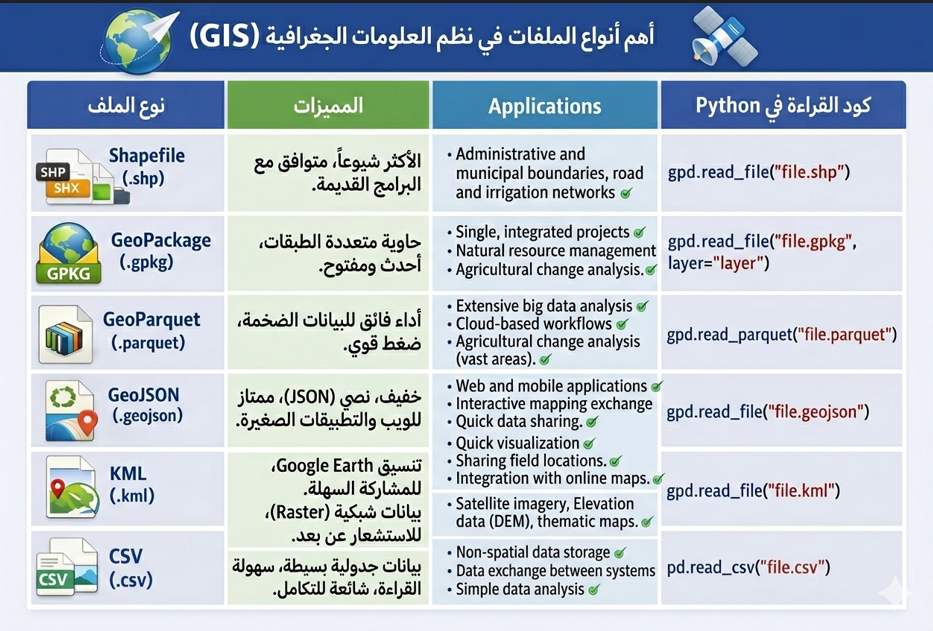

In [ ]:
# import necessary libraries
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os

**Creating a GeoDataFrame from scratch**

In [ ]:
data = {
    "City": ["Cairo", "Riyadh", "Rabat"],
    "Latitude": [30.0444, 24.7136, 34.0209],
    "Longitude": [31.2357, 46.6753, -6.8416],
}

# Create normal DataFrame first (Pandas)
df = pd.DataFrame(data)

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]),
    crs="EPSG:4326"   # WGS84
)

In [ ]:
gdf.info()

In [ ]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

**Read Shape File**

In [ ]:
# Read Egypt ADM1 shapefile
adm1_file_path = '/content/drive/MyDrive/2-GeoPandas Mini Course/1-Reading Geospatial Data/DATA/EGYTP_ADM_1/gadm41_EGY_1.shp'
adm_gdf = gpd.read_file(adm1_file_path)

In [ ]:
adm_gdf.head()          # showing first rows

In [ ]:
adm_gdf.tail()          # showing last rows

In [ ]:
adm_gdf.info()

In [ ]:
adm_gdf['NAME_1'].unique()         # list of unique values in a column

**Writing Geospatial Data**

In [ ]:
#Define your save folder directory
output_folder = '/content/drive/MyDrive/2-GeoPandas Mini Course/1-Reading Geospatial Data/OUTPUT'

In [ ]:
# Writing to a GeoJSON File
geojson_file = os.path.join(output_folder, 'Egy_Adm1.geojson')
adm_gdf.to_file(geojson_file, driver="GeoJSON")

print(f"GeoDataFrame has been written to {geojson_file}")

In [ ]:
# Writing to a Shapefile
shp_file = os.path.join(output_folder, 'Egy_Adm1.shp')
adm_gdf.to_file(shp_file)

print(f"GeoDataFrame has been written to {shp_file}")

In [ ]:
# Writing to a Geopackage
gpkg_file = os.path.join(output_folder, 'Egy_Adm1.gpkg')
adm_gdf.to_file(gpkg_file , driver = 'GPKG')

print(f"GeoDataFrame has been written to {gpkg_file}")

**Plotting**

In [ ]:
# plot adm_gdf map
fig, ax = plt.subplots(figsize=(8, 8))

adm_gdf.plot(edgecolor="black" , ax=ax)

ax.set_title("Egypt Governorates")
#ax.set_axis_off()

plt.show()

# Save Figure
#fig.savefig(os.path.join(output_folder, "egypt_governorates.png"),dpi=300 , bbox_inches="tight")  # Uncomment to use

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

adm_gdf.plot(
    column="NAME_1",
    ax=ax,
    legend=False
)

ax.set_title("Egypt Governorates")
# ax.set_axis_off()

plt.show()

# Save Figure
#fig.savefig(os.path.join(output_folder, "egypt_governorates_color.png"),dpi=300 , bbox_inches="tight")  # Uncomment to use

In [ ]:
# Name of governorate to highlight
selected_gov = "Al Iskandariyah"

fig, ax = plt.subplots(figsize=(8, 8))

# Plot all governorates
adm_gdf.plot(
    ax=ax,
    edgecolor="black",
    )

# Plot selected governorate on top in red
adm_gdf[adm_gdf["NAME_1"] == selected_gov].plot(
    ax=ax,
    color="red",
    edgecolor="black",
    )

ax.set_title(f"{selected_gov}")
#ax.set_axis_off()

plt.show()

# Save Figure
#fig.savefig(os.path.join(output_folder, "al buhayra_governorate.png"),dpi=300 , bbox_inches="tight")  # Uncomment to use